In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/SeoulBikeData.csv", encoding="latin1")
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.shape
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [5]:
df.duplicated().sum()


np.int64(0)

In [6]:
df["Date"].head()

0    01/12/2017
1    01/12/2017
2    01/12/2017
3    01/12/2017
4    01/12/2017
Name: Date, dtype: str

In [7]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df["Date"].head()

0   2017-12-01
1   2017-12-01
2   2017-12-01
3   2017-12-01
4   2017-12-01
Name: Date, dtype: datetime64[us]

In [8]:
df["Date"].dtype

dtype('<M8[us]')

In [9]:
df["Weekday"] = df["Date"].dt.day_name()
df[["Date","Weekday"]].head()



,Date,Weekday
0,2017-12-01,Friday
1,2017-12-01,Friday
2,2017-12-01,Friday
3,2017-12-01,Friday
4,2017-12-01,Friday


### Date preparation
The Date column was converted from a string to a datetime data type.  
A new Weekday column was derived from Date for later analysis of weekly rental patterns.

Next Question for Analysis: How is bicycle-rental demand distributed, and what is the average rental demand at different hours of the day?

In [17]:
df["Rented Bike Count"].describe()


count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: Rented Bike Count, dtype: float64

Does count equal 8,760? If yes, what does that suggest?
- it suggests the total count 
Is the mean higher or lower than the median?
- the mean is higher than the median of (504.50000)
How large is the difference between the median and maximum?
The difference is 3556-504 = 3052
Are zero-rental observations possible?
the mininum is zero so it is possible. 
Does the large maximum suggest that demand changes considerably across different hours?
yes


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


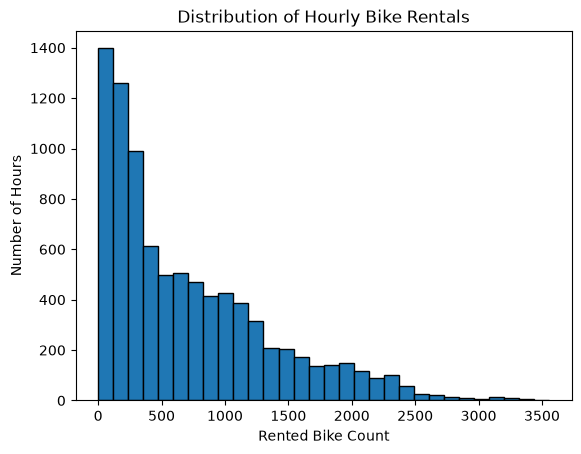

In [18]:
%pip install matplotlib
import matplotlib.pyplot as plt

df["Rented Bike Count"].plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.xlabel("Rented Bike Count")
plt.ylabel("Number of Hours")
plt.title("Distribution of Hourly Bike Rentals")
plt.show()

In [19]:
df["Functioning Day"].unique()
df.groupby("Functioning Day")["Rented Bike Count"].describe()

,count,mean,std,min,25%,50%,75%,max
Functioning Day,,,,,,,,
No,295.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Yes,8465.0,729.156999,642.351166,2.0,214.0,542.0,1084.0,3556.0


The dataset contains 295 non-functioning hours, and all of them recorded zero rentals. During functioning hours, rentals ranged from 2 to 3,556 bicycles. Therefore, zero values represent unavailable service rather than genuine zero demand.

In [20]:
working_df = df[df["Functioning Day"] == "Yes"].copy()
working_df.shape

(8465, 15)

In [21]:
working_df["Rented Bike Count"].describe()

count    8465.000000
mean      729.156999
std       642.351166
min         2.000000
25%       214.000000
50%       542.000000
75%      1084.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

Next Question: How does average rental demand change across the 24 hours of the day?